# TR1 catalogue analysis: galaxy density per tomographic bin

This notebook checks the (weighted) effective galaxy number density of the real TR1 Euclid-like shear catalogue, broken down per tomographic bin and combined across all bins, using the same mask and density formula as `TR1_power_spectra_and_covariance_estimation.ipynb`.

### Necessary imports

In [8]:
import os
import numpy as np
import fitsio
import healpy as hp

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.use('Agg')
plt.rcParams['text.usetex'] = False
sns.set(font_scale=1.25, rc={'text.usetex': False, 'figure.dpi': 300})

In [14]:
%matplotlib inline

## Data paths and mask

Same real Euclid effective-coverage mask and shear catalogue used by the TR1 QML pipeline notebook.

In [9]:
root_filepath = '/home/vscode/WeakLensingQML'
tr1_dir = f'{root_filepath}/TR1'
pipeline_input_dir = f'{tr1_dir}/pipeline_input'

n_side = 256

coverage_filepath = f'{pipeline_input_dir}/EUC_LE3_VMPZ-ID_HPEFFECTIVECOVERAGE-CONCAT-20251204T094108.787432Z_0.12.fits'
she_catalog_filepath = f'{pipeline_input_dir}/EUC_LE3_WLCATALOG-CONCAT-20251218T164508.418188Z_00.00.fits'

The f_sky of the real survey mask (n_side=256) is 0.371 %


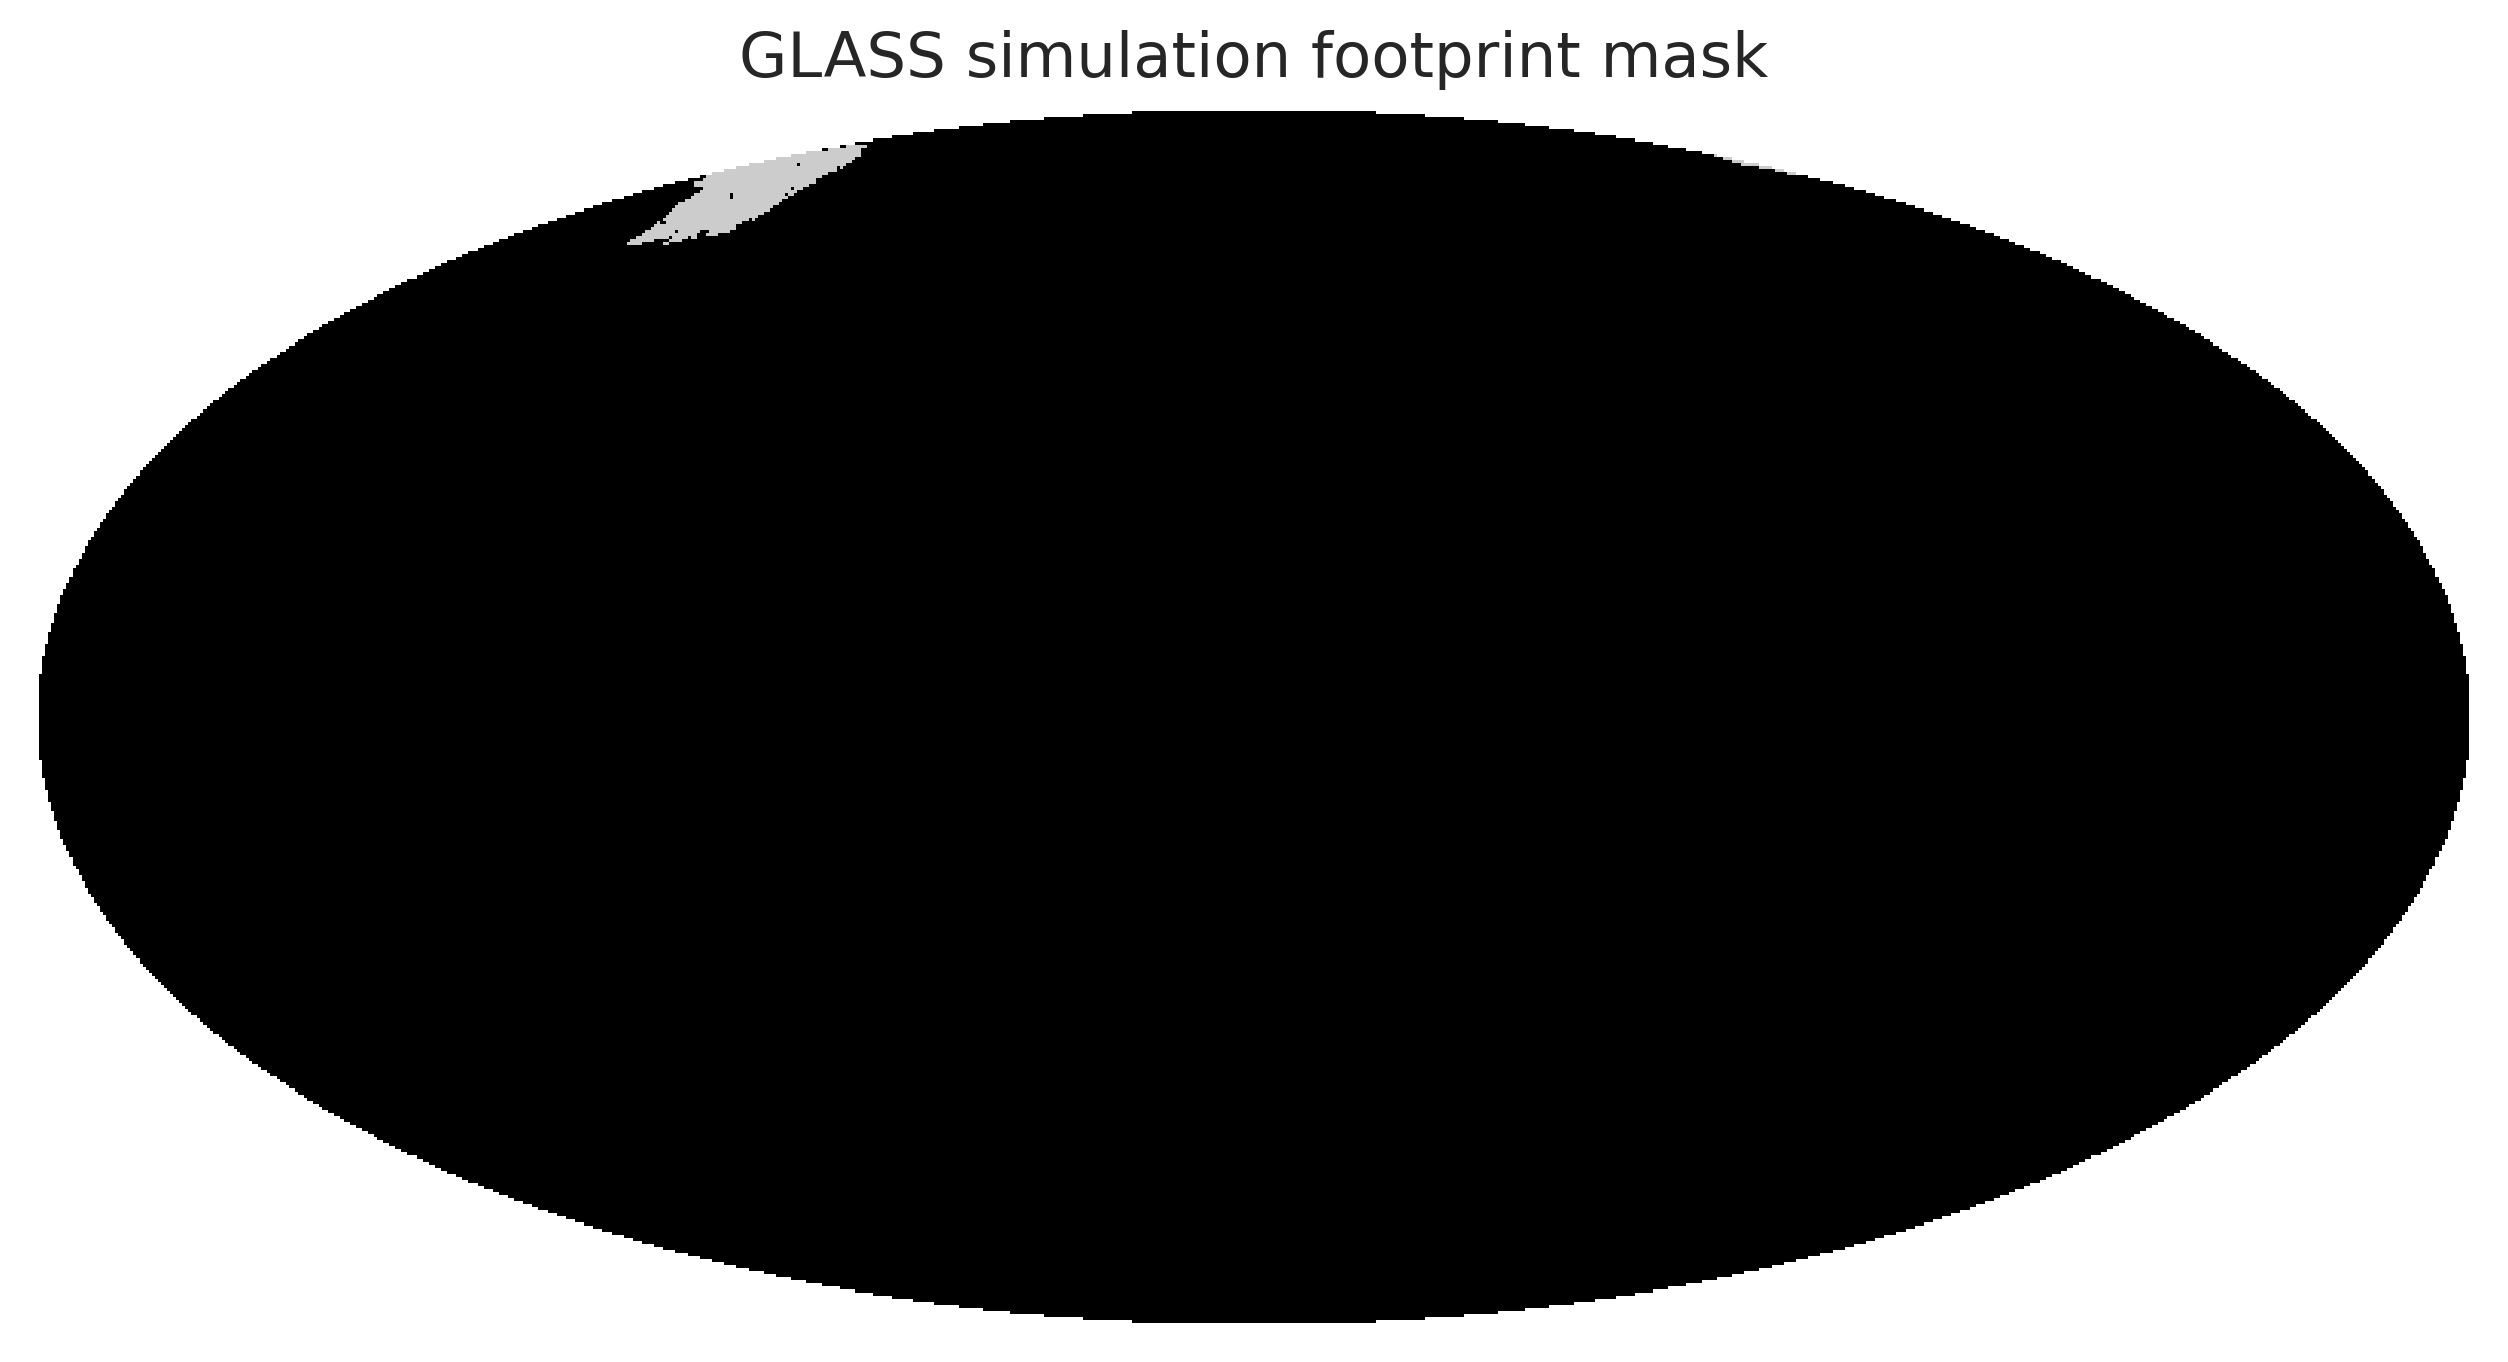

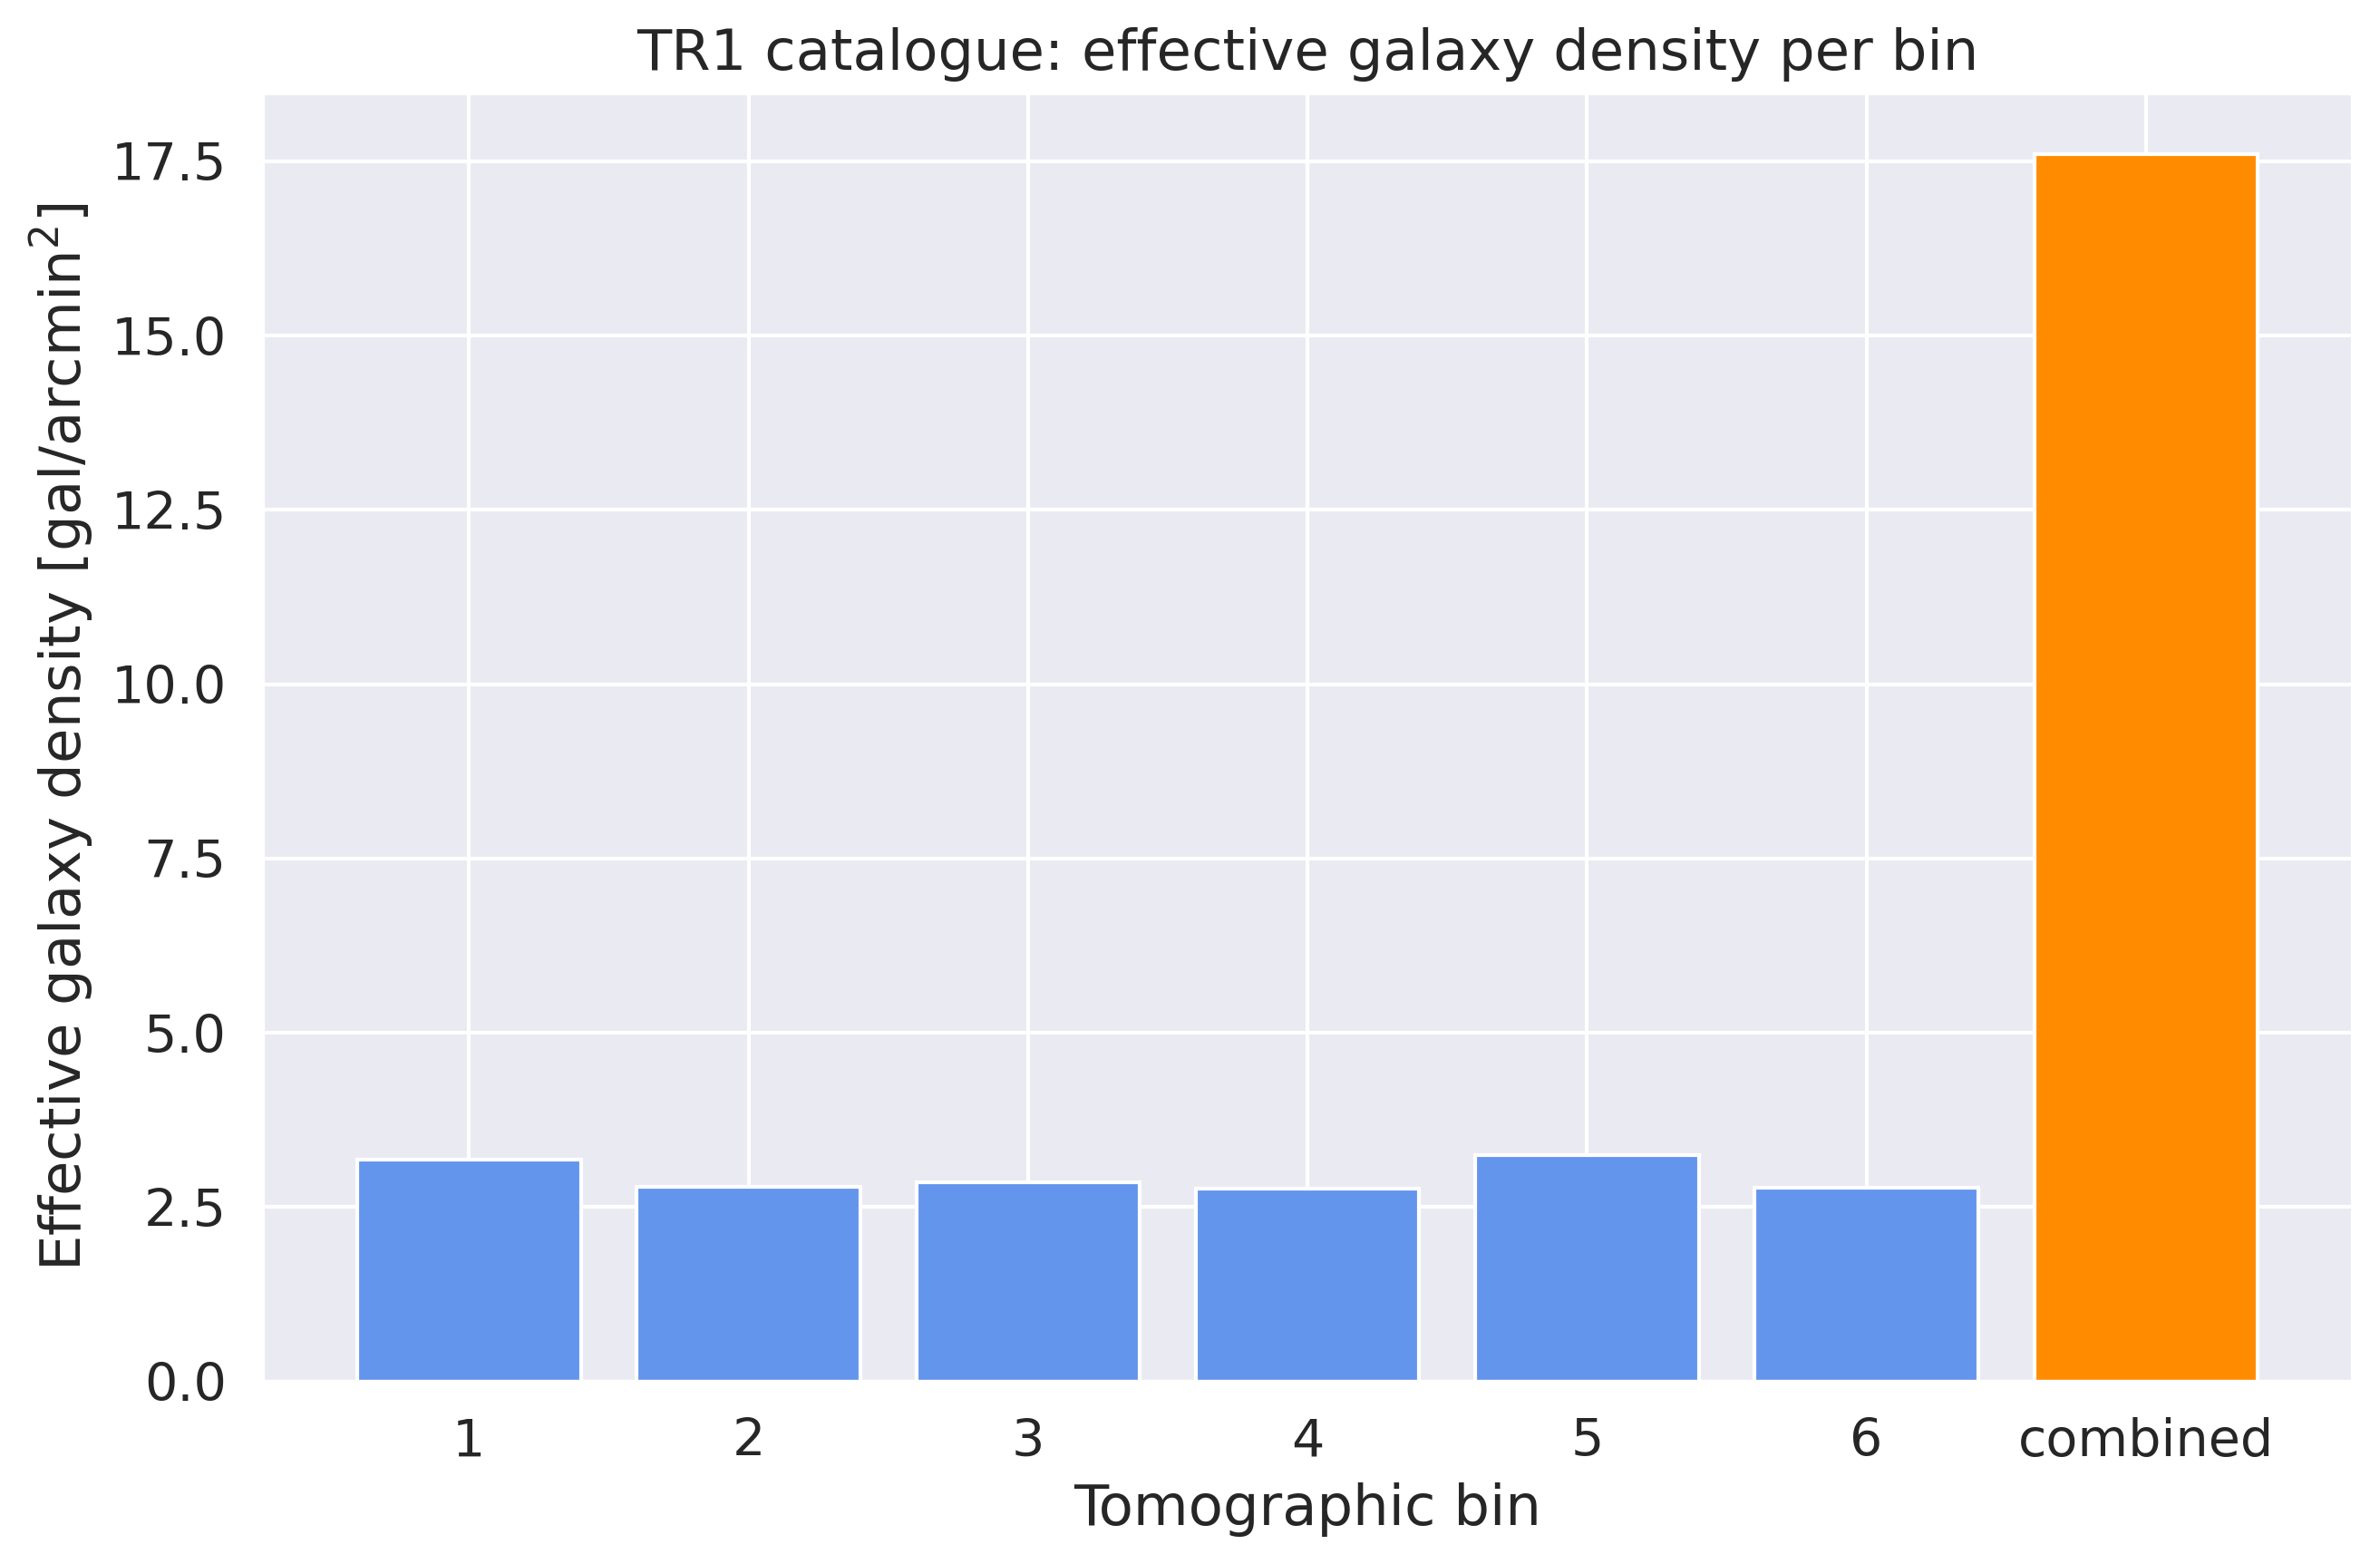

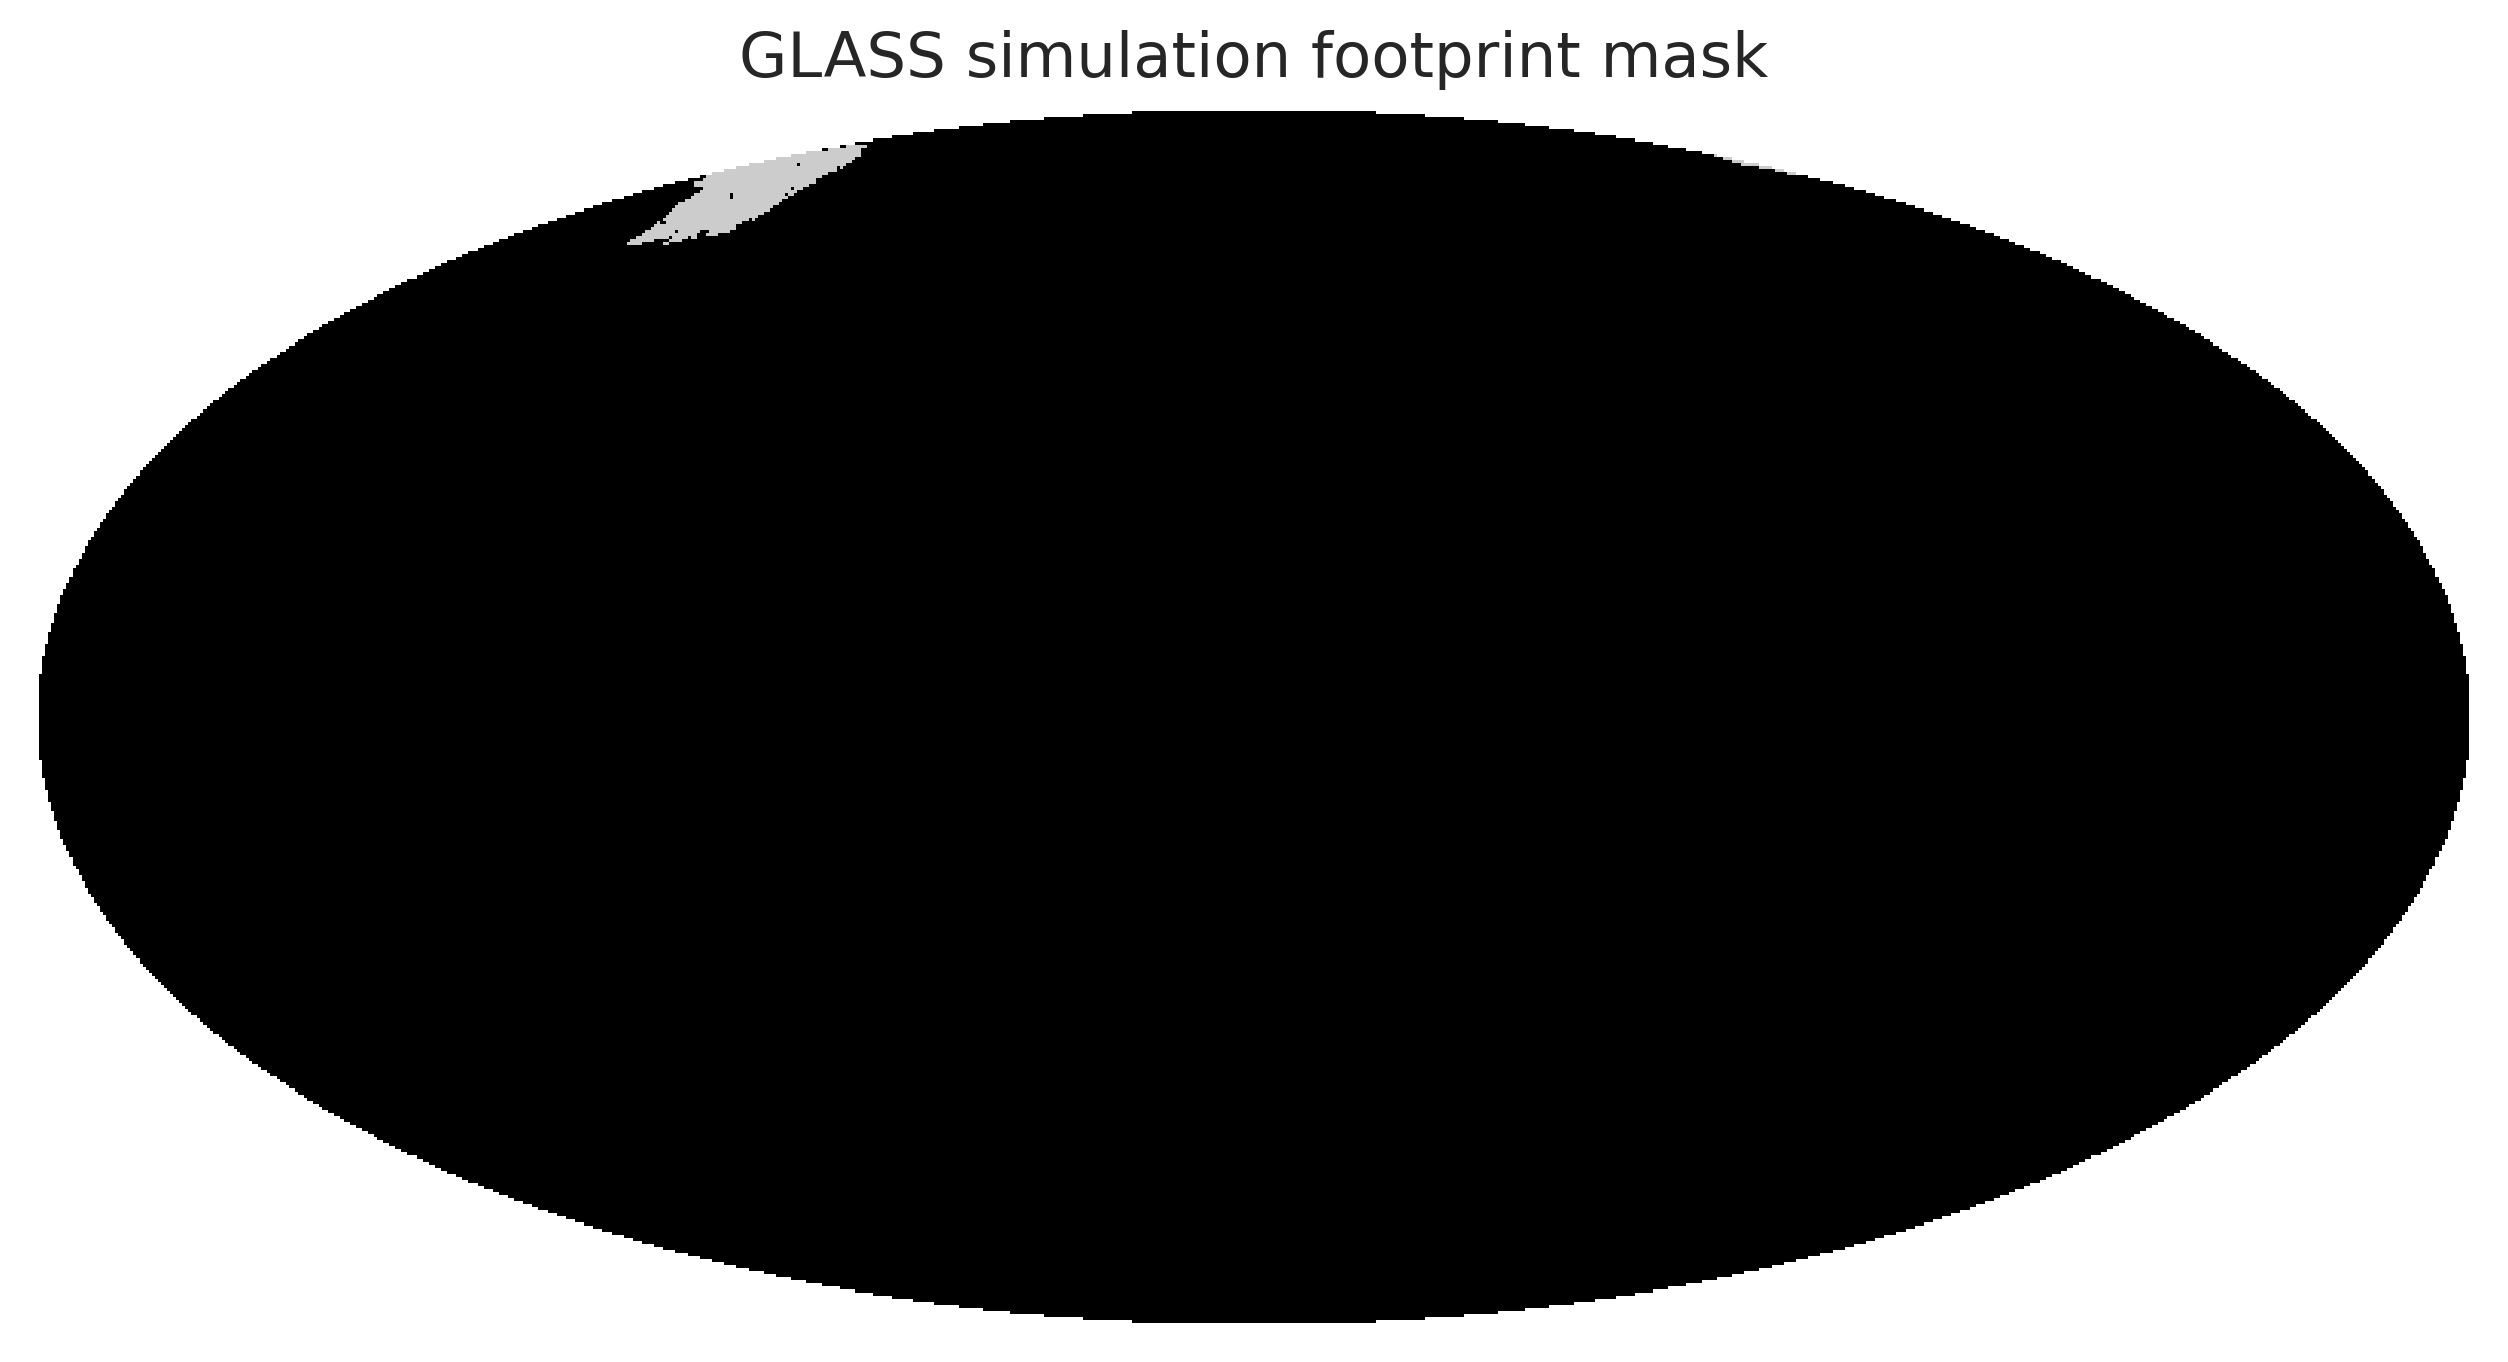

In [15]:
def read_partial_map(path, nside, *, nest=False):
    """
    Read a HEALPix map in "partial" format from *path* and return it at resolution *nside*.
    The returned NSIDE cannot be larger than the NSIDE of the stored map.
    """
    data, header = fitsio.read(path, header=True)
    nside_in = header['NSIDE']
    fact = (nside_in // nside) ** 2
    if fact == 0:
        raise ValueError(f'requested NSIDE={nside} greater than map NSIDE={nside_in}')
    out = np.zeros(12 * nside ** 2)
    ipix, wht = data['PIXEL'], data['WEIGHT']
    order = header['ORDERING']
    if order == 'RING':
        ipix = hp.ring2nest(nside_in, ipix)
    elif order != 'NESTED':
        raise ValueError(f'unknown pixel ordering {order} in map')
    ipix = ipix // fact
    if not nest:
        ipix = hp.nest2ring(nside, ipix)
    np.add.at(out, ipix, wht / fact)
    return out


# Read the real effective-coverage map and downgrade it directly to our QML resolution
coverage = read_partial_map(coverage_filepath, n_side)
mask = (coverage > 0)

f_sky = mask.sum() / mask.size
area_mask = f_sky * 4 * np.pi  # steradians
arcmin2_per_steradian = (180 / np.pi) ** 2 * 3600

print(f'The f_sky of the real survey mask (n_side={n_side}) is {(f_sky * 100):.3f} %')

plt.rcParams['text.usetex'] = False
hp.mollview(mask, cmap='nipy_spectral', cbar=False, title='GLASS simulation footprint mask')
plt.show()


## Read the shear catalogue

Only the columns needed for a density calculation (`SHE_WEIGHT`, `TOM_BIN_ID`) are read, to keep this fast even though the full catalogue also carries positions/ellipticities.

In [11]:
she_data = fitsio.read(she_catalog_filepath, columns=['SHE_WEIGHT', 'TOM_BIN_ID'])
she_weight_all = she_data['SHE_WEIGHT'].astype(np.float64)
tom_bin_id = she_data['TOM_BIN_ID']

tom_bins = np.unique(tom_bin_id)
print(f'Tomographic bins found in catalogue: {tom_bins}')

Tomographic bins found in catalogue: [1 2 3 4 5 6]


## Effective galaxy density per bin (and combined)

Uses the same effective-number/density formula as the main pipeline notebook: `n_eff = (sum w)^2 / sum(w^2)`, converted to galaxies/arcmin^2 over the real mask's unmasked footprint. Note `n_eff` is not additive across bins (it depends on the weight distribution), so the combined row is computed directly from all rows' weights, not by summing the per-bin values.

In [12]:
def effective_density(weights):
    n_eff = np.sum(weights) ** 2 / np.sum(weights ** 2)
    return n_eff, n_eff / (area_mask * arcmin2_per_steradian)


bin_labels = [str(b) for b in tom_bins] + ['combined']
n_eff_per_bin = []
density_per_bin = []

for b in tom_bins:
    n_eff, density = effective_density(she_weight_all[tom_bin_id == b])
    n_eff_per_bin.append(n_eff)
    density_per_bin.append(density)

n_eff_combined, density_combined = effective_density(she_weight_all)
n_eff_per_bin.append(n_eff_combined)
density_per_bin.append(density_combined)

print(f'{"Bin":>10} {"n_eff":>15} {"density [gal/arcmin^2]":>25}')
for label, n_eff, density in zip(bin_labels, n_eff_per_bin, density_per_bin):
    print(f'{label:>10} {n_eff:15,.1f} {density:25.3f}')

       Bin           n_eff    density [gal/arcmin^2]
         1     1,749,116.8                     3.176
         2     1,539,506.8                     2.796
         3     1,572,048.7                     2.855
         4     1,525,570.0                     2.770
         5     1,787,683.1                     3.246
         6     1,530,455.6                     2.779
  combined     9,694,646.2                    17.605


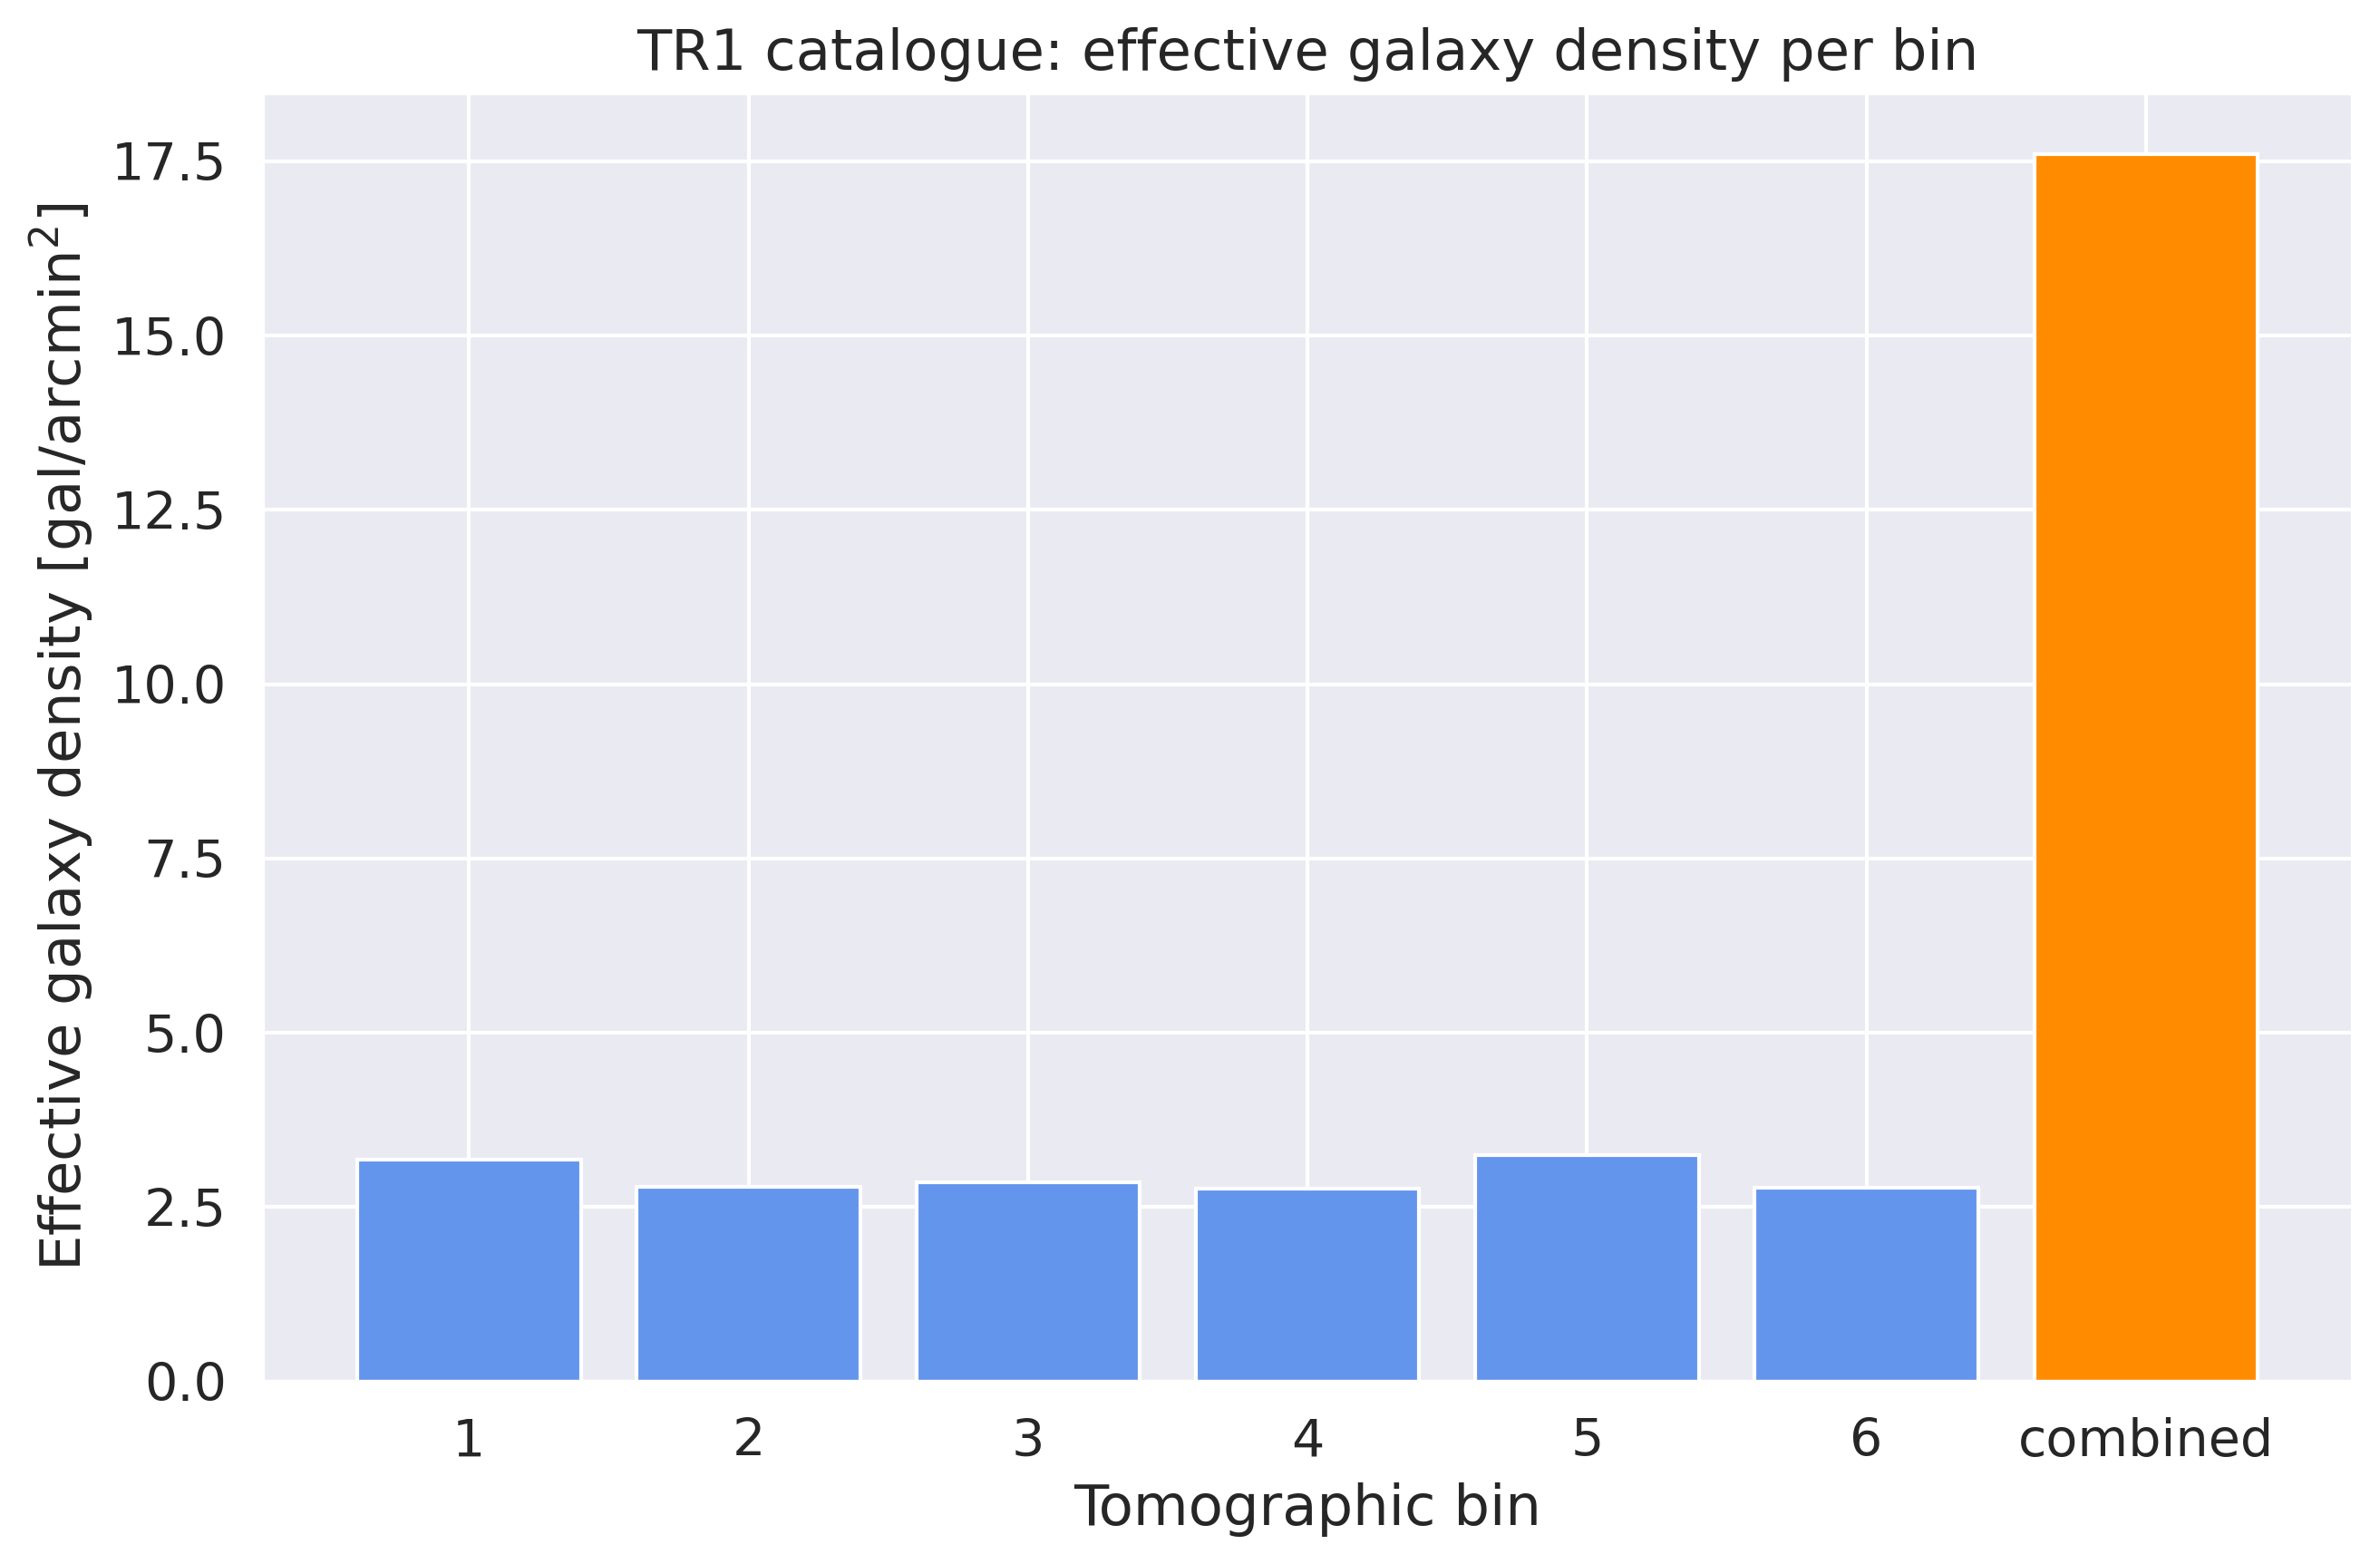

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['cornflowerblue'] * len(tom_bins) + ['darkorange']
ax.bar(bin_labels, density_per_bin, color=colors)

ax.set_xlabel('Tomographic bin')
ax.set_ylabel(r'Effective galaxy density [gal/arcmin$^2$]')
ax.set_title('TR1 catalogue: effective galaxy density per bin')

plt.tight_layout()
plt.show()